In [1]:
# Stage 1: 双解码器VAE训练
# 使用Dual Decoder架构 + MMD对齐SC和ST模态
%run stage1.py \
    --sc_file "/mnt/d/ST_Graduation_Project/database/PDAC/PDAC_SC.h5ad" \
    --st_file "/mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad" \
    --n_epochs 50 \
    --resolution 3 \
    --loss_type zinb \
    --beta 0.1 \
    --lambda_mmd 1.0 \
    --top_n_per_type 200 \
    --latent_dim 256 \
    --output_dir ./stage1_results/PDAC 

# \
#     --precomputed_marker_file "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage1_results/PDAC/final_genes.txt"

/home/mwc/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 200
   Leiden resolution: 3.0
   Batch size: 256
   Epochs: 50
   Learning rate: 0.001
   Beta (KL weight): 0.1
   Hidden dims: [512, 256]
   Latent dim: 256
   Loss type: ZINB
   Lambda MMD: 1.0
   Dual Decoder: True
Loading datasets...
   Loading SC: /mnt/d/ST_Graduation_Project/database/PDAC/PDAC_SC.h5ad
   SC shape: (1926, 19738)
   SC avg counts/cell: 3302.8 (from X)
   Loading ST: /mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad
   SC shape: (1926, 19738)
   SC avg counts/cell: 3302.8 (from X)
   Loading ST: /mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad
   ST shape: (428, 19738)
   Common genes: 19738
   SC final: (1926, 19738)
   ST final: (428, 19738)
Computing clusters and marker genes...
Starting clustering analysis...
   ST shape: (428, 19738)
   Common genes: 19738
   SC final: (1926, 19738)
   ST final: (428, 19738)
Computing clusters and marker genes..

VAE Training: 100%|██████████| 50/50 [00:16<00:00,  3.03epoch/s, Train=1691.4603, Recon=1686.0470, KL=54.1317, MMD=0.0308, Test=1759.6523]



Computing cluster centers...
   SC training data: (1733, 1319)
   Number of clusters: 35
   Computing full gene cluster expressions...
      Total genes: 19738
   Completed: 35 clusters with center and expressions (all genes)
Visualizing modality alignment...
Generating UMAP visualization for modality alignment...
   Computing UMAP on 2118 samples with 256 dims...
   UMAP visualization saved to: ./stage1_results/PDAC/modality_alignment_umap.png
Saving model to: ./stage1_results/PDAC/final_vae.pth
   Cluster centers: 35 clusters
   Cluster expressions (marker genes): 35 clusters
   Cluster expressions (all genes): 35 clusters
   Cluster expressions (all genes, count backup): 35 clusters
   Average cell counts: 3302.8 (for Stage 2 scale factor)
   Saved successfully!
   UMAP visualization saved to: ./stage1_results/PDAC/modality_alignment_umap.png
Saving model to: ./stage1_results/PDAC/final_vae.pth
   Cluster centers: 35 clusters
   Cluster expressions (marker genes): 35 clusters
   Clu

---

Sample name: PDAC
Stage 1 model: ./stage1_results/PDAC/final_vae.pth
Output directory: ./stage2_results/PDAC/
Device: cpu
Weight threshold: 0.01
Loading pretrained VAE Encoder...
   VAE architecture: 1319 -> 256
   Output type: zinb
   Architecture: Dual Decoder (SC/ST-specific)
   ✓ Loaded 1926 cell cluster labels from checkpoint
Loaded cluster centers: torch.Size([35, 256])
Loaded cluster expressions: torch.Size([35, 1319])
Loaded avg_cell_counts: 3302.8 (for scale factor calculation)
Loaded full gene expressions (count): 35 clusters × 19738 genes
Loaded all genes list: 19738 genes
VAE Encoder loaded: 1319 -> 256
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '4', '5', '6', '7', '8', '9']
Marker genes: 1319
Using Stage 1 cluster centers and expressions...
Loaded 35 clusters
Using Stage 1 pretrained cluster data
   Cluster centers: torch.Size(

GAT Training: 100%|██████████| 500/500 [07:49<00:00,  1.06epoch/s, Total=81.2590, Pearson=0.5767, MSE=765.3608, Cosine=0.4539, Proportion=0.6497]



Evaluating model results...
Cells per spot: 0.7063970186672854
Applying weight threshold: 0.01
   Non-zero elements: 12840 -> 7318 (48.9%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
Applying weight threshold: 0.01
   Non-zero elements: 12840 -> 7318 (48.9%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Full gene expression...
   Cell type composition...
   Found duplicate celltype names: ['Cancer', 'Ductal']. Merging corresponding cluster columns by summing weights.
   Columns before: 35, after merge: 11
   Cell type composition...
   Found duplicate celltype names: ['Cancer', 'Ductal']. Merging corresponding cluster columns by summing weights.
   Columns before: 35, after merge: 11
   Saved cell composition (celltype): ./stage2_results/PDAC//PDAC_cell_composition.csv
   Saved cluster composition: ./stage2_results/PDAC//PDAC_clus

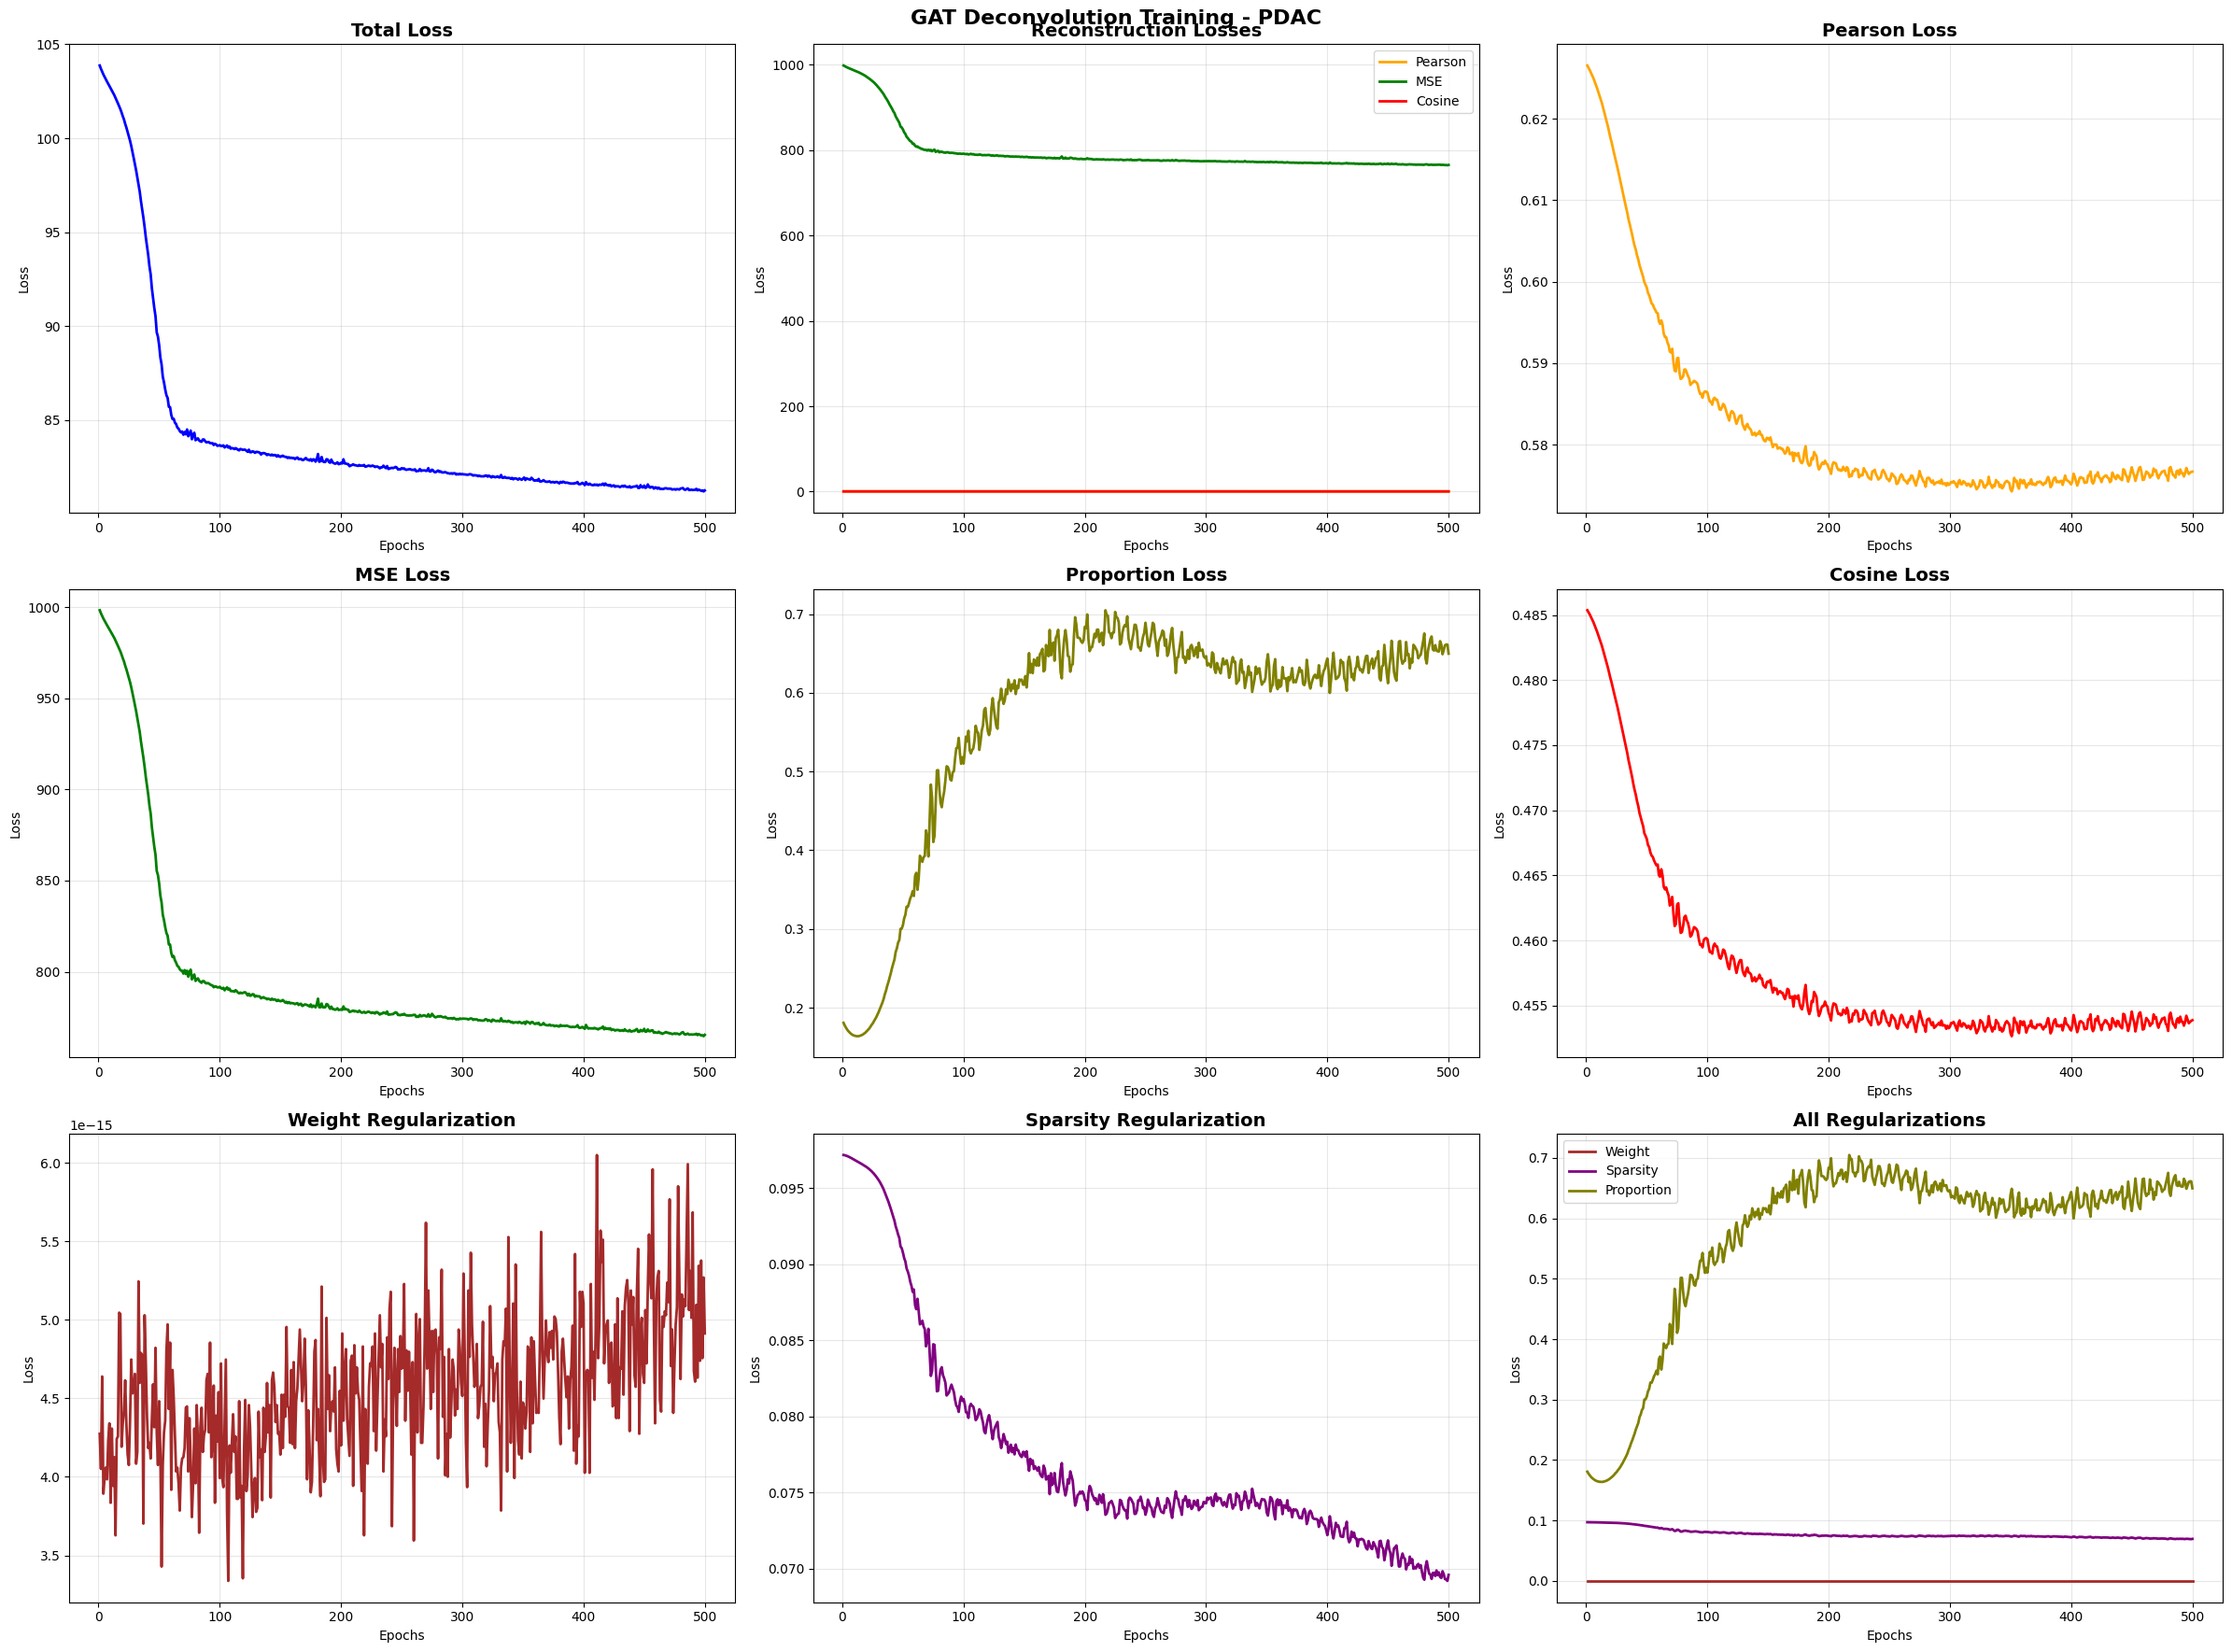

In [2]:
# k_celltype 影响比较大
# cells_per_spot 会自动计算（如果需要手动指定，添加 --cells_per_spot 10）
%run stage2.py \
    --st_file "/mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad" \
    --stage1_model_path "./stage1_results/PDAC/final_vae.pth" \
    --output_dir "./stage2_results/PDAC/" \
    --gat_hidden_dim 512 \
    --gat_layers 4 \
    --lr 1e-4 \
    --loss_lambda_mse 0.1 \
    --loss_lambda_cosine 5 \
    --loss_lambda_pearson 2 \
    --loss_lambda_reg 0.1 \
    --loss_lambda_sparse 0.01 \
    --loss_lambda_proportion 2 \
    --k_spatial 10 \
    --k_celltype 30 \
    --batch_size 512 \
    --n_epochs 500 \
    --weight_threshold 0.01